In [30]:
#Import de bibliothèques
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.tree import plot_tree

In [31]:
#Chargement du dataset breast_cancer
breast_cancer=load_breast_cancer()
X=breast_cancer.data
Y=breast_cancer.target
feature_names=breast_cancer.feature_names
class_names=breast_cancer.target_names
print("Dimension de X:",X.shape)
print("Dimension de Y:",Y.shape)



Dimension de X: (569, 30)
Dimension de Y: (569,)


In [33]:
#Séparation train et test
(X_train,X_test,Y_train,Y_test)=train_test_split(X,Y,test_size=0.3,random_state=42,stratify=Y)

In [50]:
#Entrainement du RandomForest
rf_model=RandomForestClassifier(n_estimators=100,         #le nombre d'arbres choisi est 100
                                max_depth=6,              # Évite que les arbres soient trop profonds
                                min_samples_split=5,      # Empêche de créer des branches pour 1 ou 2 individusrandom_state=42) 
                                random_state=42 )
    

In [51]:
#Entrainement du RandomForest 
rf_model.fit(X_train,Y_train)
#Prédiction
Y_pred=rf_model.predict(X_test)


In [52]:
#Evaluation
accuracy=accuracy_score(Y_test,Y_pred)
print("Accuracy du RandomForest:",accuracy)
print("Matrice de confusion pour RandomForest:",confusion_matrix(Y_test,Y_pred))
print("Rapport de classification:")
print(classification_report(Y_test,Y_pred))

Accuracy du RandomForest: 0.9473684210526315
Matrice de confusion pour RandomForest: [[ 58   6]
 [  3 104]]
Rapport de classification:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        64
           1       0.95      0.97      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



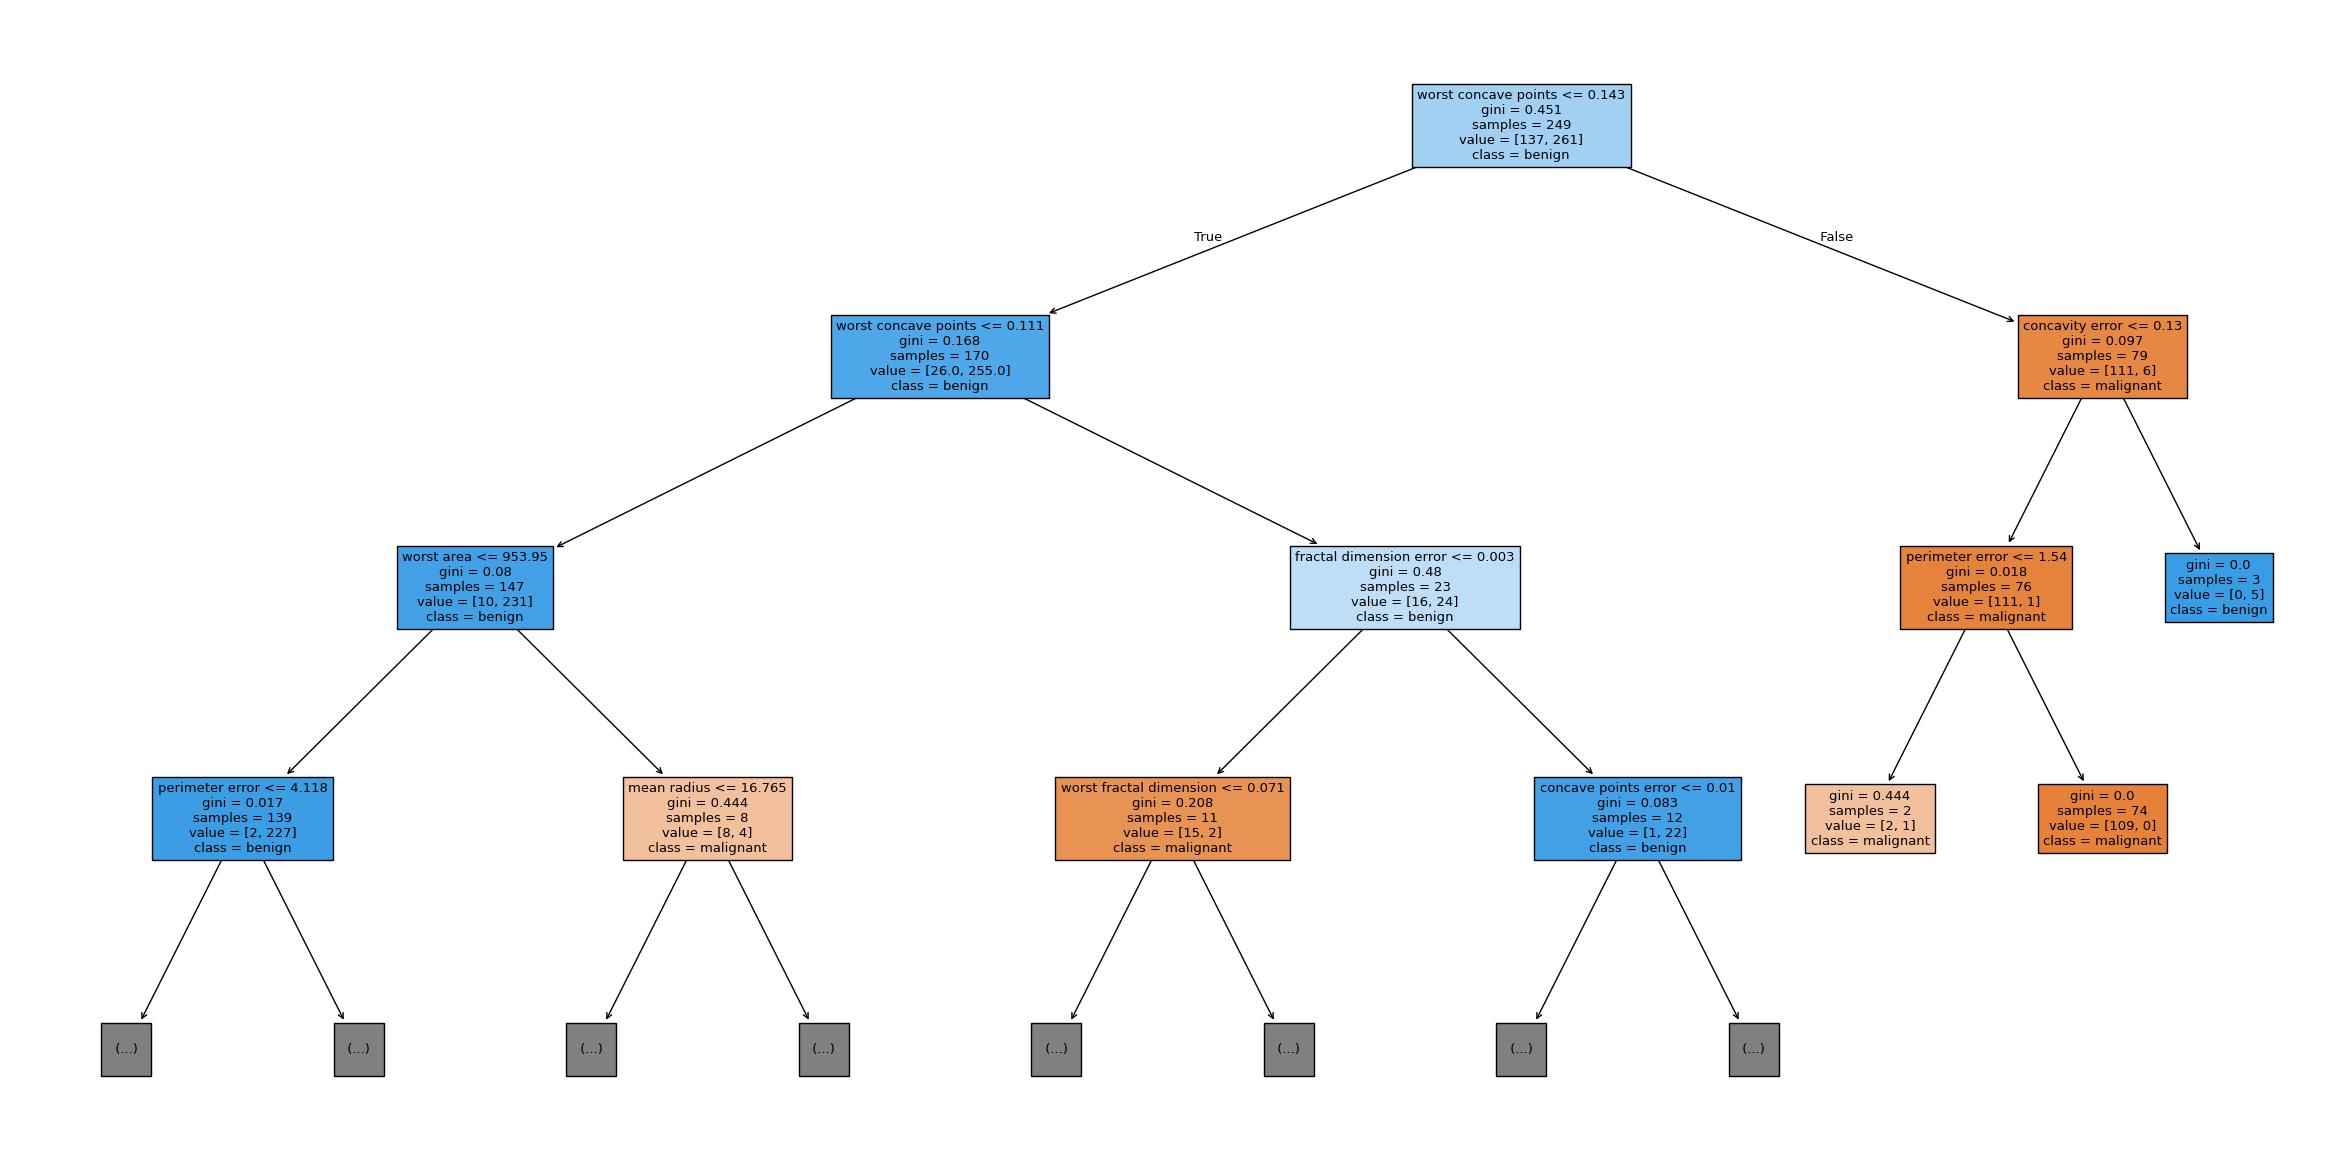

In [53]:
#Visualisation 
plt.figure(figsize=(30,15))
plot_tree(
    rf_model.estimators_[0],
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    max_depth=3
)
plt.show()

In [54]:
#Les importances
feature_importances = rf_model.feature_importances_
importance_df=pd.DataFrame({
   "Feature":feature_names,
    "Importance":feature_importances}).sort_values(by="Importance",ascending=False)
print(importance_df)

                    Feature  Importance
27     worst concave points    0.167497
23               worst area    0.159644
22          worst perimeter    0.087869
0               mean radius    0.080402
20             worst radius    0.073994
2            mean perimeter    0.068841
7       mean concave points    0.068320
6            mean concavity    0.055174
3                 mean area    0.042440
26          worst concavity    0.031461
25        worst compactness    0.023449
13               area error    0.019737
24         worst smoothness    0.015194
5          mean compactness    0.013861
28           worst symmetry    0.012149
10             radius error    0.010654
21            worst texture    0.010405
29  worst fractal dimension    0.009256
1              mean texture    0.008178
12          perimeter error    0.007642
4           mean smoothness    0.006167
16          concavity error    0.004536
17     concave points error    0.004308
19  fractal dimension error    0.003857


In [55]:
#Comparaison avec un arbre de décision
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(
    random_state=42
)
dt_model.fit(X_train,Y_train)
Y_pred_dt=dt_model.predict(X_test)
accuracy_dt=accuracy_score(Y_test,Y_pred_dt)
print("Accuracy du decision tree:",accuracy_dt)
print("Accuracy du Random Forest:",accuracy)
print("Arbre de décision  -> Train:", dt_model.score(X_train, Y_train), "| Test:", dt_model.score(X_test, Y_test))
print("RandomForest -> Train:", rf_model.score(X_train, Y_train), "| Test:", rf_model.score(X_test, Y_test))

Accuracy du decision tree: 0.9181286549707602
Accuracy du Random Forest: 0.9473684210526315
Arbre de décision  -> Train: 1.0 | Test: 0.9181286549707602
RandomForest -> Train: 0.992462311557789 | Test: 0.9473684210526315


Le Random Forest **surclasse** l'arbre de décision de près de 3% sur le Test. C'est la preuve concrète de **la puissance des méthodes d'ensemble (bagging)** : la combinaison d'arbres légèrement contraints donne un **modèle final beaucoup plus robuste et stable**.
